In [1]:
import sys
import os

# Example 2: xarray Projection Maps, Shear-Periodic Tiling, and Star-Cluster Cutouts

This notebook demonstrates how to:
1. Convert projection maps to a labelled `xarray.Dataset`.
2. Expand the domain using shear-periodic boundary conditions (needed to avoid
   edge artefacts when extracting cutouts near the boundary).
3. Extract a time-series of spatial cutouts centred on individual star clusters
   and inspect their local environment as the cluster ages.

In [2]:
# use your pyathena installation path
sys.path.insert(0,'/home/changgoo/pyathena_master')
sys.path.insert(0,'../script/')

In [3]:
from loadsim import load_sim, load_data, prj_to_xarray, get_cutout

In [4]:
model="R8-b1-Z1.0"
s=load_sim(model)

[LoadSim-INFO] basedir: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0
[LoadSim-INFO] savdir: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0
[LoadSim-INFO] load_method: xarray
[FindFiles-INFO] athinput: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0/athinput.runtime
[FindFiles-INFO] athena_pp: False
[FindFiles-INFO] problem_id: R8_8pc_NCR
[FindFiles-WARNING] vtk files not found in /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0
[FindFiles-INFO] hst: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0/hst/R8_8pc_NCR.hst
[FindFiles-INFO] sn: /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0/hst/R8_8pc_NCR.sn
[FindFiles-WARNING] zprof files not found in /scratch/gpfs/changgoo/TIGRESS-NCR-projection-maps/notebook/../script/../data/R8-b1-Z1.0
[FindFile

xi_CR0 not found. Use 2e-16.


## 1. Load the simulation object and a snapshot

In [5]:
load_data(s,300)

In [6]:
ds = prj_to_xarray(s,expand_domain=True)

## 2. Convert to xarray and expand the domain

`prj_to_xarray` attaches physical coordinates (pc) and a time stamp.
Setting `expand_domain=True` tiles the domain with shear-periodic copies so
that cutouts extracted near the boundary are seamless.  The tiled domain is
cropped to 2× the original size (one extra copy per side).

The resulting Dataset fields are:
| Field | Description | Units |
|---|---|---|
| `Sigma_gas` | Total gas surface density | M☉ pc⁻² |
| `Sigma_H2` | H₂ surface density | M☉ pc⁻² |
| `Sigma_HI` | H I surface density | M☉ pc⁻² |
| `EM` | Emission measure (∫ n_e² dl) | cm⁻⁶ pc |

In [7]:
ds

<xarray.Dataset> Size: 1MB
Dimensions:    (y: 256, x: 256)
Coordinates:
  * x          (x) float64 2kB -1.02e+03 -1.012e+03 ... 1.012e+03 1.02e+03
  * y          (y) float64 2kB -1.02e+03 -1.012e+03 ... 1.012e+03 1.02e+03
    time       float64 8B 300.0
Data variables:
    Sigma_gas  (y, x) float32 262kB 16.9 18.34 20.19 21.81 ... 13.09 9.477 7.575
    Sigma_H2   (y, x) float32 262kB 1.314 1.637 1.974 ... 1.627e-06 1.66e-06
    Sigma_HI   (y, x) float32 262kB 15.59 16.71 18.21 ... 13.08 9.477 7.575
    EM         (y, x) float32 262kB 1.404 1.412 1.394 1.4 ... 61.52 78.0 89.45

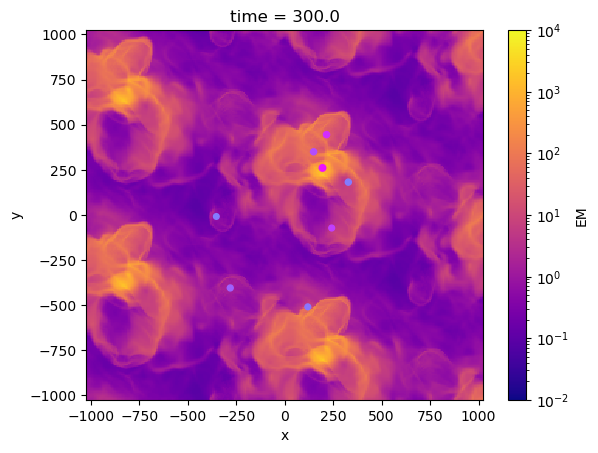

In [8]:
ds["EM"].plot(norm=LogNorm(1.0e-2, 1.0e4),cmap=plt.cm.plasma,)

from pyathena.plt_tools.plt_starpar import scatter_sp, colorbar_sp, legend_sp
scatter_sp(s.sp_src, plt.gca(), "z", kpc=False, norm_factor=5, u=s.u, agemax=40)

## 3. Visualise the EM map with source star particles

`s.sp_src` contains only active (mass > 0, age < 20 Myr) star particles —
the ionising/CR source population used in TIGRESS-NCR.

# Extract cutouts

In [ ]:
# Build a dictionary of per-particle cutout time-series.
# Key: star-particle ID (float).
# Value: list of single-snapshot cutout Datasets, later concatenated along "time".
cutouts = dict()

# Loop over snapshots (first 50 shown here for demonstration; use s.nums for all).
for num in s.nums[:50]:
    load_data(s, num)
    # Convert to xarray without domain expansion — cutouts near the boundary
    # will be handled later if needed.
    ds = prj_to_xarray(s)

    # Restrict to very young (<10 Myr) source particles for tighter selection.
    sp_src = s.sp_src.loc[lambda df: df["mage"] < 10]

    # Extract a cutout centred on every qualifying particle in this snapshot.
    for id_ in sp_src.id:
        sp = sp_src.loc[lambda df: df["id"] == id_]
        # iloc[0] converts the 1-row DataFrame to a Series for get_cutout.
        cutout = get_cutout(ds, sp.iloc[0])
        if id_ in cutouts:
            # Particle already seen in an earlier snapshot — append this cutout.
            cutouts[id_] += [cutout]
        else:
            # First appearance of this particle — start a new list.
            cutouts[id_] = [cutout]

In [ ]:
# Concatenate each particle's list of single-snapshot Datasets along the "time" dimension.
# After this step, cutouts[id_] is a 3-D Dataset: (time, y, x).
for id_ in cutouts:
    cutouts[id_] = xr.concat(cutouts[id_], dim="time")

In [11]:
# check particle ids
ids = list(cutouts.keys())
print(ids)

[3515.0, 3551.0, 3594.0, 3714.0, 3738.0, 3788.0, 3825.0, 3826.0, 3850.0, 3859.0, 3867.0, 3892.0, 3902.0, 3923.0, 3927.0, 3930.0, 3941.0, 3950.0, 4004.0, 4017.0, 4072.0, 4201.0, 4261.0, 4288.0, 4456.0, 4489.0, 4568.0, 4600.0]


In [12]:
# visualize cutouts from a selected particle
id_=ids[10]

## 5. Inspect and plot cutouts for a selected particle

Each cutout Dataset has dimensions `(time, y, x)` and scalar coordinates
`x0/y0` (grid-snapped centre), `xp/yp` (exact particle position), `mage`
(mean age at each snapshot), and `mass`.  The spatial coordinates `x` and `y`
are relative to the particle centre (pc).

In [13]:
cutouts[id_]

<xarray.Dataset> Size: 47kB
Dimensions:    (time: 10, y: 17, x: 17)
Coordinates:
  * time       (time) float64 80B 217.0 218.0 219.0 220.0 ... 224.0 225.0 226.0
  * x          (x) float64 136B -64.0 -56.0 -48.0 -40.0 ... 40.0 48.0 56.0 64.0
  * y          (y) float64 136B -64.0 -56.0 -48.0 -40.0 ... 40.0 48.0 56.0 64.0
    x0         (time) float64 80B 172.0 172.0 172.0 164.0 ... 156.0 156.0 156.0
    y0         (time) float64 80B -388.0 -388.0 -396.0 ... -428.0 -436.0 -436.0
    xp         (time) float64 80B 171.5 170.5 169.3 167.7 ... 159.2 156.6 153.8
    yp         (time) float64 80B -384.2 -391.0 -397.6 ... -427.9 -433.3 -438.4
    mage       (time) float64 80B 0.6141 1.615 2.615 3.615 ... 7.615 8.615 9.615
    mass       float64 8B 3.897e+05
Data variables:
    Sigma_gas  (time, y, x) float32 12kB 14.65 21.76 37.62 ... 15.9 14.12 12.15
    Sigma_H2   (time, y, x) float32 12kB 6.779e-07 0.002029 ... 7.441e-05
    Sigma_HI   (time, y, x) float32 12kB 14.65 21.75 37.2 ... 15.89 14.12 12.15
    EM         (time, y, x) float32 12kB 293.4 227.6 173.1 ... 47.42 48.37 52.87

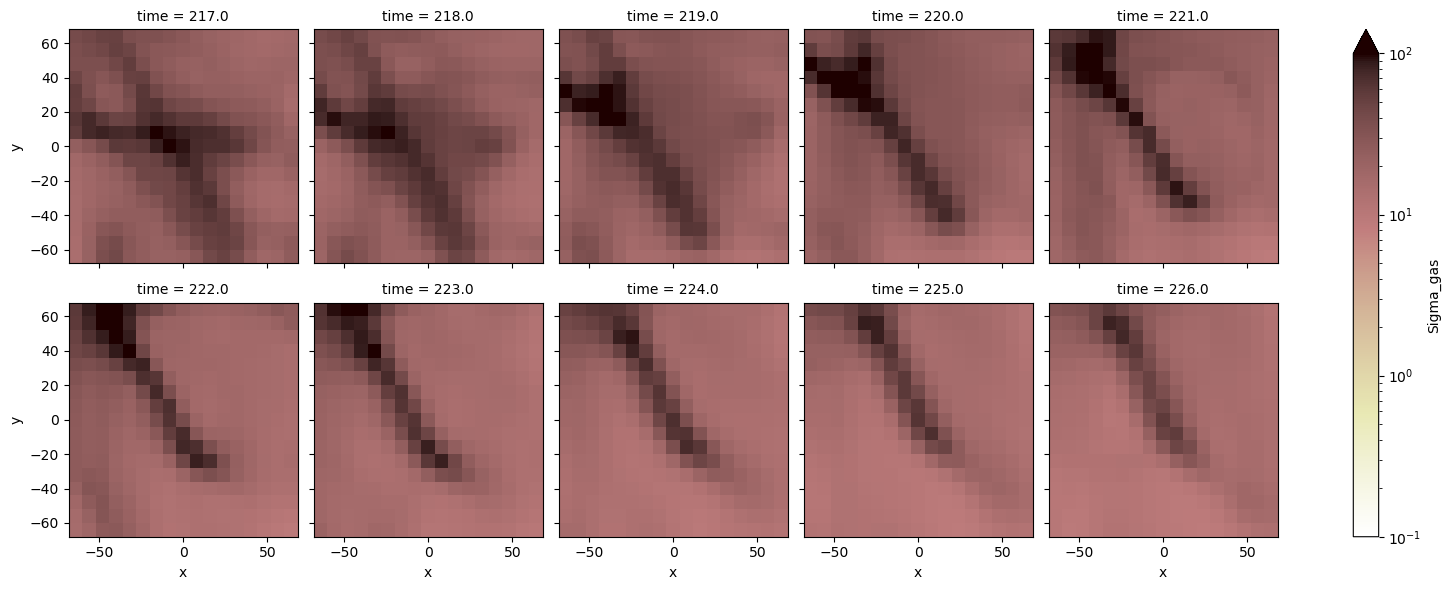

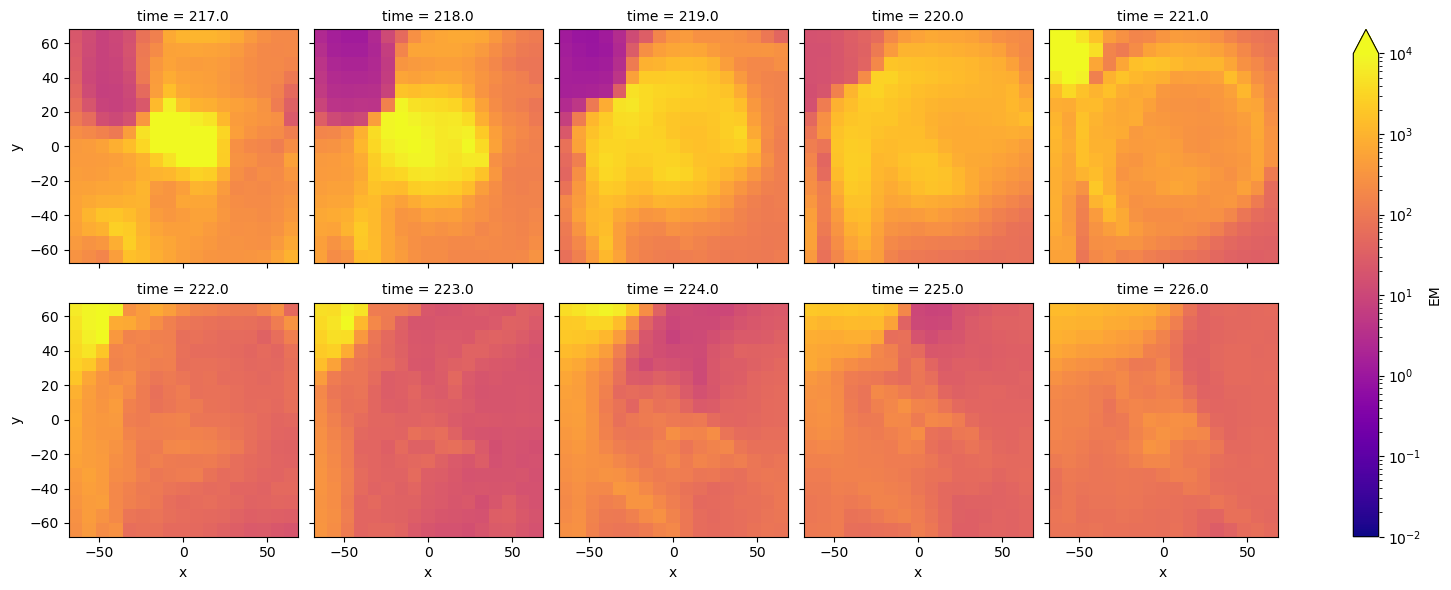

In [19]:
cutouts[id_]["Sigma_gas"].plot(col="time",col_wrap=5,
                                norm=LogNorm(1.0e-1, 1.0e2),
                                cmap=plt.cm.pink_r)
cutouts[id_]["EM"].plot(col="time",col_wrap=5,
                         norm= LogNorm(1.0e-2, 1.0e4),
                         cmap=plt.cm.plasma)